# Radio Modulation Classification with FINN - Notebook #2 of 5

### Overview 
In this Notebook we again load the dataset and create our dataloader. Then we:
1. Define our model using Brevitas
2. Train, and test our new Brevitas model!

Portions of this notebook that have been covered in the previous notebook will have much less description (such as the dataloader). The more information please see the Tutorial1_Dataset_and_Vanilla_model.ipynb file!

### FINN Pipeline Map
Throughout these notebooks, you will begin to understand the FINN pipeline! In order the pipeline is:
1. Dataset and Vanilla model
2. **Brevitas Model** (you are here)
3. Transforming the Brevitas Model to tidy.onnx
4. Transforming tidy.onnx to bitstream
5. Loading the bitstream on the FPGA!

We are in **2. Brevitas Model.** This notebook will show you how to define a VGG-10 model using the Brevitas Framework, which allows us to quantize the model (i.e make a smaller model). Having a quantized model is required for the next steps of the pipeline!


### Packages, and Data 
First we import the required packages and create the dataloader for the dataset. The details of this are explained in Notebook 1.

In [1]:
# Import necessary packages
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
import time

# Prepare data loader
from torch.utils.data import Dataset, DataLoader
import h5py
from sklearn.metrics import accuracy_score

In [2]:
# Using cuda 
assert torch.cuda.is_available(), 'Cuda not available'
gpu = 'cuda'

In [3]:
# Check if dataset is present
import os.path
# dataset_path = "datasets/new_normalized/MatGenData_ppm20_rician_20250828.h5"
# dataset_path = "datasets/new_normalized/MatGenData_20_ppm_Rician_10062025.h5"
# dataset_path = "datasets/MatGenData.h5"
# dataset_path = "mat_gen_2bit_10302025/MatGenData_ppm0_rician_int8_20251030.h5"
dataset_path="datasets/new_normalized/quantized_rician_matgen_ppm0/MatGenData_ppm0_rician_int8_20251006.h5"
os.path.isfile(dataset_path)

True

## Parameters

In [4]:
from experimental.dataset_tools import radioml_dataset
from experimental.dataset_tools import base_dataset_quantizer, standard_int8_norm, standard_int4_norm, standard_int2_norm
# data_key='all_IQ_int8'
# data_key='all_IQ_float32'
data_key='all_IQ_8bit'
mod_key='all_labels'
snr_key='all_SNRs'
snr_lower_bound=0.0
snr_upper_bound=30.0
snr_steps=2.0

mod_classes = ["BPSK", 
                "QPSK", 
                "8PSK",
                "16QAM",
                "32QAM", 
                "64QAM", 
                "128QAM", 
                "256QAM",
                "16APSK", 
                "32APSK", 
                "64APSK", 
                "128APSK",
                "FM", 
                "AM-DSB-SC", 
                "AM-SSB-SC"]

snr_classes = np.arange(snr_lower_bound,
                        snr_upper_bound+1.0,
                        snr_steps) 

In [5]:
quantization_dtype=np.int8
# quantizer=standard_int8_norm(-3.2, 3.2, np.int8)
# quantizer=standard_int4_norm(-3.2, 3.2, np.int8)
# quantizer=standard_int2_norm(-3.2, 3.2, np.int8)
quantizer=base_dataset_quantizer()
model_input_bit:int=8
model_body_bit:int=4
new_min=-128.0
new_max=127.0

build_dir='rician_matgen_ppm0_2026_jan15_report/mat_gen_4bit' #directory to save model
model_file_name='model_4bit.pth' #name of the pth file
Path(build_dir).mkdir(exist_ok=True)
chpt_path=build_dir+'/'+model_file_name
print(f'Model parameters will be saved in {chpt_path}')

#Ensuring path exist, otherwise create an empty directory
Path(f"{build_dir}/onnx_models/").mkdir(exist_ok=True)
export_path=f"{build_dir}/onnx_models/matgen_ppm0_brevitas.onnx" #Full name of the path of the model with the tail _export.onnx

Model parameters will be saved in rician_matgen_ppm0_2026_jan15_report/mat_gen_4bit/model_4bit.pth


## Load Dataset

In [6]:
# quantizer=simple_linear_scale_quantizer(5.5, 128, np.int8)
dataset = radioml_dataset(dataset_path=dataset_path,
                          data_key=data_key, mod_key=mod_key, snr_key=snr_key,
                          mod_classes=mod_classes,snr_classes=snr_classes,
                          dataset_quantizer=quantizer,
                          frame_per_mod_snr_combination=4096) 

debug_quantized_dataset=quantizer.quantize(dataset.data[:])

print('Raw value range: (',np.min(dataset.data),' ; ',np.max(dataset.data),')  ',dataset.data.dtype) 
print('Quantized value range: (',np.min(debug_quantized_dataset),' ; ',np.max(debug_quantized_dataset),')  ',debug_quantized_dataset.dtype) 
print('Total mods: ', len(dataset.mod_classes))
print('Number of SNRs: ',len(dataset.snr_classes))
print('Number of frames per each SNR-Modulation combination: ',
      dataset.data.shape[0]/(len(dataset.mod_classes)*len(dataset.snr_classes)))
print('SNRs: ',dataset.snr_classes,' \n')
print('Total size: ', dataset.data.shape)
print('Training set size: ',len(dataset.train_sampler))
print('Val set size: ',len(dataset.val_sampler))
print('Test set size: ',len(dataset.test_sampler))

All available keys: ['all_IQ_8bit', 'all_SNRs', 'all_labels']
Extracting data key all_IQ_8bit
Get labels
Get SNR
Raw value range: ( -128  ;  127 )   int8
Quantized value range: ( -128  ;  127 )   int8
Total mods:  15
Number of SNRs:  16
Number of frames per each SNR-Modulation combination:  4096.0
SNRs:  [ 0.  2.  4.  6.  8. 10. 12. 14. 16. 18. 20. 22. 24. 26. 28. 30.]  

Total size:  (983040, 1024, 2)
Training set size:  786480
Val set size:  98400
Test set size:  98160


# Some visualizations of Dataset

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

raw_sample = dataset.data[:]  #Get the data as (1,2,1024)
# Flatten the array to 1D
raw_flattened = raw_sample.flatten()  
# quantized_flatten = debug_quantized_dataset.flatten()  

## Histogram plotting values vs their frequencies

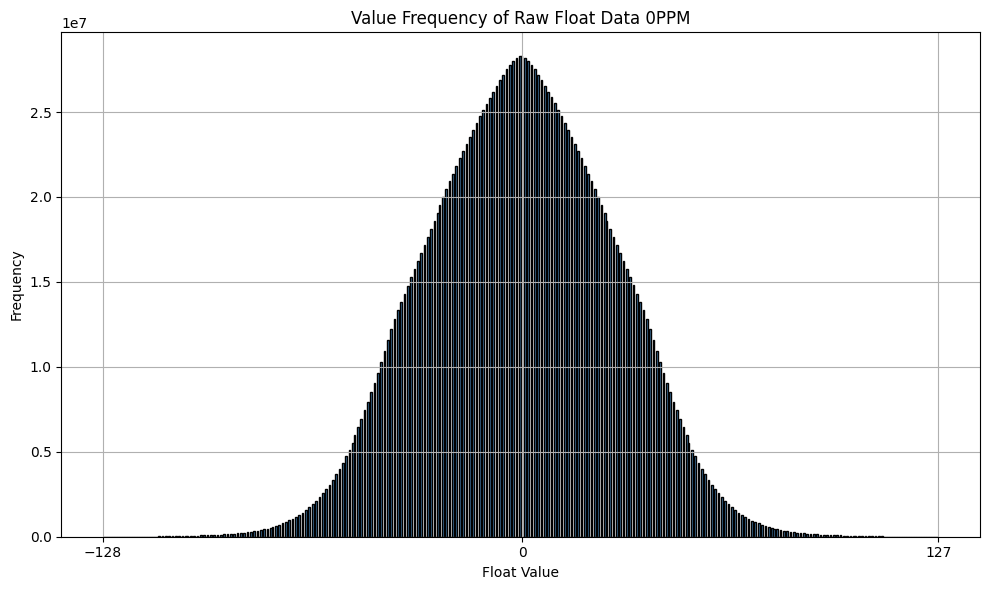

32217

In [8]:
# Plot raw dataset histogram
plt.figure(figsize=(10, 6))
plt.hist(raw_flattened, bins=500, color='steelblue', edgecolor='black', density=False)
plt.title('Value Frequency of Raw Float Data 0PPM')
# plt.xticks([-6,-3.2,-2,0,2,3.2,6])
plt.xticks([-128,0.0,127])
plt.xlabel('Float Value')
plt.ylabel('Frequency')

plt.grid(True)
plt.tight_layout()
plt.show()

# # Plot quantized dataset histogram
# plt.figure(figsize=(10, 6))
# plt.hist(quantized_flatten, bins=500, color='steelblue', edgecolor='black', density=False)
# plt.title('Value Frequency of Quantized Data 0PPM')
# # plt.xlim(-128, 127)
# plt.xticks([new_min,new_min*0.5,0,new_max*0.5,new_max])
# plt.xlabel('Float Value')
# plt.ylabel('Frequency')

# plt.grid(True)
# plt.tight_layout()
# plt.show()

import gc
##Flush these variables to save memory
raw_sample = None
raw_flattened = None
# quantized_flatten = None
gc.collect()

## Save the quantized dataset as H5

In [9]:
# quantized_dataset_name="MatGenData_ppm20_rician_int2_2025.h5"
# dataset.save_as_h5(output_path = build_dir+"/"+quantized_dataset_name,
#                    data_key = 'all_IQ_2bit', 
#                    mod_key = 'all_labels', 
#                    snr_key = 'all_SNRs',
#                    apply_quantization = True)

# Build the VGG-10 model
This model is built with Brevitas (and Pytorch for non-parameters layers), meaning this model has already been quantized before training. 


## Brevitas Quantization at a Highlevel 

Brevitas _heavily abstracts_ the idea of quantizing and therefore gives us a lot of customization options! By definition quantizing is performing _some_ operation on a value to reduce it's precision. More informally, given some value that takes A bits to represent, change it to a new value that uses less than A bits to represent. 

Therefore, Brevitas is built upon the idea of defining **Custom Quantizers**. The quantizers are modules that allow the user to:
1. Select which parts {Weights, Bias, Input, Outputs} of a layer get quantized
2. The method by which each part of each layer is quantized {Custom, or defualts such as power of 2 quantization, scaled uniform, etc. brevitas defines _alot_ of quantization types}

Specifically, we can define 3 custom modules {WeightQuantType, BiasQuantType, ActQuantType}. The first two are used to quantize the Weights and Bias respectively, and the last one is used to quantize inputs and outputs of a layer. 


For example, below we use `Int8ActPerTensorFloatMinMaxInit` to define a ActQuantizer. This quantizer takes 3 parameters: bit_width, min_val, max_val. This will force corresponding tensors to have values between the min_val and max_val, and will be represented with bit_width bits.  

Formally, we define our quantizer as `InputQuantizer`, which inherits from `Int8ActPerTensorFloatMinMaxInit`. Meaning we can now use our quantizer **to enforce our quantizing rules** on a new layer! While verbose, you may now see the power we have to define very custom quantizers. 

Here is a tutorial to make your own quantizer: https://xilinx.github.io/brevitas/tutorials/anatomy_quantizer.html. 


#### Specifics 

**QuantRelu:** Implements a standard ReLu layer _followed_ by quantization 

**QuantConv1d:** This is an instance of both a standard Conv2d layer and QuantWeightBiasInputOutputLayer (QuantWBIOL) layer. A WBIOL layer is a layer that **allows for** quantizing of Weights, Bias, Inputs, and Outputs. Allow for, meaning, it does not by default enable quantization for all those layers, but if a user so wishes, they can choose to enable quantization for all those layers 

**QuantLinear:** Another WBIOL layer, this time combined with a Linear Layer. 


The default type of quantization for these layers is: Int8WeightPerTensorFloat, meaning the Wieghts are quantized to 8bit floats. However you can see in our implementation we specify a `weight_bit_width` and a `bias`. So we explicity set bias to false (which is redundant but good practice) and set weight_bit_width to a value that we can now customize! 


In [10]:
# Setting seeds for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Adjustable hyperparameters
input_bits = model_input_bit #The same bit width as the new loaded dataset
a_bits = model_body_bit  # a_bits is the bit width for ReLu
w_bits = model_body_bit # w_bits is the bit width for all the weights
filters_conv = 64
filters_dense = 128

In [11]:
chpt_path=Path(f'{build_dir}/model_brevitas.pth')
onnx_file=Path(f'{build_dir}/model_brevitas.onnx')

print(f'Model parameters will be saved in {chpt_path}')
print(f'input value has max range [{new_min}, {new_max}]')

Model parameters will be saved in rician_matgen_ppm0_2026_jan15_report/mat_gen_4bit/model_brevitas.pth
input value has max range [-128.0, 127.0]


In [12]:
from torch import nn

# A qnn is a Brevitas version of pytorch's nn. nn stands for neural network.
import brevitas.nn as qnn
from brevitas.quant import Int8Bias
from brevitas.inject.enum import ScalingImplType
from brevitas.inject.defaults import Int8ActPerTensorFloatMinMaxInit

class InputQuantizer(Int8ActPerTensorFloatMinMaxInit):
    #Quantize to input_bits
    bit_width = input_bits
    
    #Min max value of the input. Set to the range value of the input 
    min_val = new_min #the min value of the input(dataset) before going through the model
    max_val = new_max #the max value of the input(dataset) before going through the model
    scaling_impl_type = ScalingImplType.CONST # Fix the quantization range to [min_val, max_val]

model_class = nn.Sequential(
    # Input quantization layer
    qnn.QuantHardTanh(act_quant=InputQuantizer),

    qnn.QuantConv1d(2, filters_conv, 3, padding=1, weight_bit_width=w_bits, bias=False),
    nn.BatchNorm1d(filters_conv),
    qnn.QuantReLU(bit_width=a_bits),
    nn.MaxPool1d(2),

    qnn.QuantConv1d(filters_conv, filters_conv, 3, padding=1, weight_bit_width=w_bits, bias=False),
    nn.BatchNorm1d(filters_conv),
    qnn.QuantReLU(bit_width=a_bits),
    nn.MaxPool1d(2),

    qnn.QuantConv1d(filters_conv, filters_conv, 3, padding=1, weight_bit_width=w_bits, bias=False),
    nn.BatchNorm1d(filters_conv),
    qnn.QuantReLU(bit_width=a_bits),
    nn.MaxPool1d(2),

    qnn.QuantConv1d(filters_conv, filters_conv, 3, padding=1, weight_bit_width=w_bits,bias=False),
    nn.BatchNorm1d(filters_conv),
    qnn.QuantReLU(bit_width=a_bits),
    nn.MaxPool1d(2),

    qnn.QuantConv1d(filters_conv, filters_conv, 3, padding=1, weight_bit_width=w_bits, bias=False),
    nn.BatchNorm1d(filters_conv),
    qnn.QuantReLU(bit_width=a_bits),
    nn.MaxPool1d(2),

    qnn.QuantConv1d(filters_conv, filters_conv, 3, padding=1, weight_bit_width=w_bits, bias=False),
    nn.BatchNorm1d(filters_conv),
    qnn.QuantReLU(bit_width=a_bits),
    nn.MaxPool1d(2),

    qnn.QuantConv1d(filters_conv, filters_conv, 3, padding=1, weight_bit_width=w_bits, bias=False),
    nn.BatchNorm1d(filters_conv),
    qnn.QuantReLU(bit_width=a_bits),
    nn.MaxPool1d(2),
    
    nn.Flatten(),

    qnn.QuantLinear(filters_conv*8, filters_dense, weight_bit_width=w_bits, bias=False),
    nn.BatchNorm1d(filters_dense),
    qnn.QuantReLU(bit_width=a_bits),

    qnn.QuantLinear(filters_dense, filters_dense, weight_bit_width=w_bits, bias=False),
    nn.BatchNorm1d(filters_dense),
    qnn.QuantReLU(bit_width=a_bits, return_quant_tensor=True),

    qnn.QuantLinear(filters_dense, 15, weight_bit_width=w_bits, bias=True, bias_quant=Int8Bias),
)
model=model_class

import torchinfo
print(torchinfo.summary(model_class,input_size=(1,2,1024),depth=1))


/usr/local/lib/python3.10/dist-packages/torch/_tensor.py:1255: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at ../c10/core/TensorImpl.h:1758.)
  return super(Tensor, self).rename(names)


Layer (type:depth-idx)                                            Output Shape              Param #
Sequential                                                        [1, 15]                   --
├─QuantHardTanh: 1-1                                              [1, 2, 1024]              --
├─QuantReLU: 1-50                                                 --                        (recursive)
├─QuantHardTanh: 1-3                                              --                        --
├─QuantConv1d: 1-4                                                [1, 64, 1024]             384
├─BatchNorm1d: 1-5                                                [1, 64, 1024]             128
├─QuantReLU: 1-6                                                  [1, 64, 1024]             1
├─QuantReLU: 1-50                                                 --                        (recursive)
├─QuantReLU: 1-8                                                  --                        (recursive)
├─MaxPool1d: 1-9 

# Train the model

In [13]:
from sklearn.metrics import accuracy_score

def train(model, train_loader, optimizer, criterion):
    # Save losses here and make sure model is in training mode.
    losses = []
    model.train()    

    # Iterate over the data and train
    for (inputs, target, snr) in tqdm(train_loader, desc="Training Batches"):#, leave=False):   
        #if gpu is not None:
        inputs = inputs.to('cuda')
        target = target.to('cuda')
                
        # forward pass
        output = model(inputs)
        loss = criterion(output, target)
        
        # backward pass + run optimizer to update weights
        optimizer.zero_grad() 
        loss.backward()
        optimizer.step()
        
        # keep track of loss value
        losses.append(loss.cpu().detach().numpy())
    return losses

def test(model, test_loader):    
    # ensure model is in eval mode
    model.eval() 
    y_true = []
    y_pred = []
   
    with torch.no_grad():
        for (inputs, target, snr) in tqdm(test_loader, desc="Testing Batches", leave=False):
            #if gpu is not None:
            inputs = inputs.to('cuda')
            target = target.to('cuda')
            output = model(inputs)
            pred = output.argmax(dim=1, keepdim=True)
            y_true.extend(target.tolist()) 
            y_pred.extend(pred.reshape(-1).tolist())
        
    return accuracy_score(y_true, y_pred)

def display_loss_plot(losses, title="Training loss", xlabel="Iterations", ylabel="Loss"):
    x_axis = [i for i in range(len(losses))]
    plt.plot(x_axis,losses)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

We are training the model for 100 epochs with a batch size of 1024 by default.
These numbers can be adjusted. We use an early stop of 10 epochs

The first epoch usually takes longer to train. 
After that, it should train faster per epoch.

In [14]:
from brevitas.export import export_qonnx
from qonnx.util.cleanup import cleanup as qonnx_cleanup

batch_size = 1024
num_epochs = 100
early_stop = 10
min_epochs=50

data_loader_train = DataLoader(dataset, batch_size=batch_size, sampler=dataset.train_sampler)
data_loader_test = DataLoader(dataset, batch_size=batch_size, sampler=dataset.test_sampler)
data_loader_val = DataLoader(dataset, batch_size=batch_size, sampler=dataset.val_sampler)

## Start Training
### Comment this block if loading model instead of training model

In [15]:
model = model.to(gpu)

# loss criterion and optimizer
criterion = nn.CrossEntropyLoss()
criterion = criterion.to(gpu)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=1)


running_loss = []
running_test_acc = []
training_time=time.time()
best_val_acc = float('-inf')
count = 0
for epoch in tqdm(range(num_epochs), desc="Epochs"):
        loss_epoch = train(model, data_loader_train, optimizer, criterion)
        val_acc = test(model, data_loader_val)
        print("Epoch %d: Training loss = %f, validation accuracy = %f" % (epoch, np.mean(loss_epoch), val_acc))

        if val_acc > best_val_acc:
            torch.save(model.state_dict(), chpt_path)
            print(f'Model checkpoint is saved in {chpt_path}')
    
            # export_qonnx(model.to('cuda'), torch.randn(1, 2, 1024).to('cuda'), export_path=onnx_file)
            # qonnx_cleanup(str(onnx_file), out_file=str(onnx_file))
            # print(f'QOnnx Model checkpoint is saved in {onnx_file}')
            best_val_acc = val_acc
            count = 0
        else:
            count+=1

        running_loss.append(loss_epoch)
        running_test_acc.append(val_acc)
        lr_scheduler.step()
    
        if count > early_stop and epoch>=min_epochs:
            print("Stopping early")
            break

training_time=time.time()-training_time
print(f'total training time: {training_time}')

#SAVE MODEL
# Save the trained parameters to disk
torch.save(model.state_dict(), chpt_path)

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/769 [00:00<?, ?it/s]

Testing Batches:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch 0: Training loss = 1.454376, validation accuracy = 0.408831
Model checkpoint is saved in rician_matgen_ppm0_2026_jan15_report/mat_gen_4bit/model_brevitas.pth


Training Batches:   0%|          | 0/769 [00:00<?, ?it/s]

...

Testing Batches:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch 49: Training loss = 1.010877, validation accuracy = 0.581707


Training Batches:   0%|          | 0/769 [00:00<?, ?it/s]

Testing Batches:   0%|          | 0/97 [00:00<?, ?it/s]

Epoch 50: Training loss = 1.054659, validation accuracy = 0.549258
Stopping early
total training time: 4372.664891958237


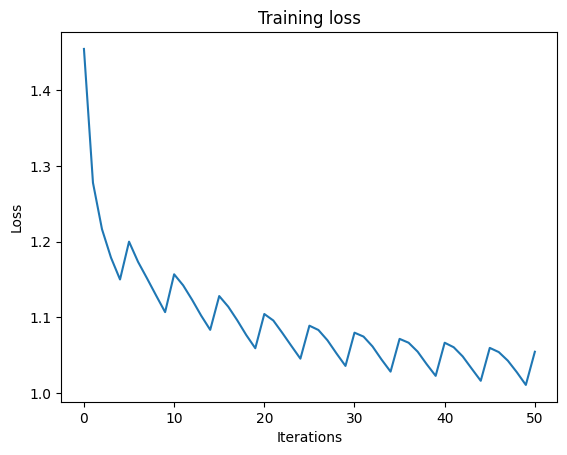

In [16]:
# Plot training loss over epochs
loss_per_epoch = [np.mean(loss_per_epoch) for loss_per_epoch in running_loss]
display_loss_plot(loss_per_epoch)

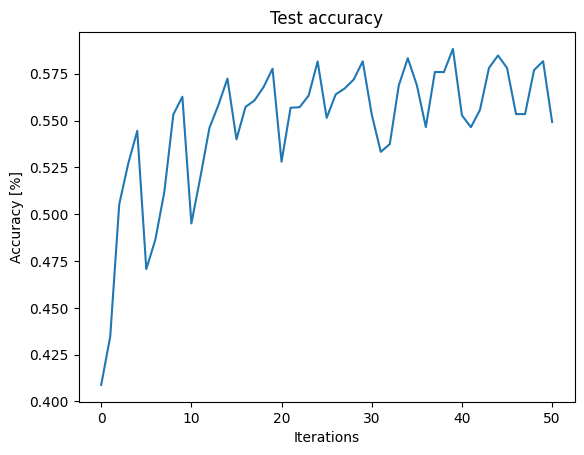

In [17]:
# Plot test accuracy over epochs
acc_per_epoch = [np.mean(acc_per_epoch) for acc_per_epoch in running_test_acc]
display_loss_plot(acc_per_epoch, title="Test accuracy", ylabel="Accuracy [%]")

## Or load a different model

In [18]:
#Load the model back again, or you can change the file to load a different model
load_path=chpt_path #Change this to a path of a different model

model=model_class 
model.load_state_dict(torch.load(load_path))
model.to('cuda')

Sequential(
  (0): QuantHardTanh(
    (input_quant): ActQuantProxyFromInjector(
      (_zero_hw_sentinel): StatelessBuffer()
    )
    (act_quant): ActQuantProxyFromInjector(
      (_zero_hw_sentinel): StatelessBuffer()
      (fused_activation_quant_proxy): FusedActivationQuantProxy(
        (activation_impl): Identity()
        (tensor_quant): RescalingIntQuant(
          (int_quant): IntQuant(
            (float_to_int_impl): RoundSte()
            (tensor_clamp_impl): TensorClamp()
            (delay_wrapper): DelayWrapper(
              (delay_impl): _NoDelay()
            )
          )
          (scaling_impl): ConstScaling(
            (restrict_clamp_scaling): _RestrictClampValue(
              (clamp_min_ste): Identity()
              (restrict_value_impl): FloatRestrictValue()
            )
            (value): StatelessBuffer()
          )
          (int_scaling_impl): IntScaling()
          (zero_point_impl): ZeroZeroPoint(
            (zero_point): StatelessBuffer()
       

# Evaluate Accuracy

In [19]:
# Run inference on validation data
y_exp = np.empty((0))
y_snr = np.empty((0))
y_pred = np.empty((0,len(dataset.mod_classes)))
model.eval()
with torch.no_grad():
    for data in tqdm(data_loader_test, desc="Batches"):
        inputs, target, snr = data
        inputs = inputs.to(gpu).float()
        output = model(inputs)
        y_pred = np.concatenate((y_pred,output.cpu()))
        y_exp = np.concatenate((y_exp,target))
        y_snr = np.concatenate((y_snr,snr))

Batches:   0%|          | 0/96 [00:00<?, ?it/s]

## Confusion Matrix across all SNRs

Overall Accuracy across all SNRs: 0.550520


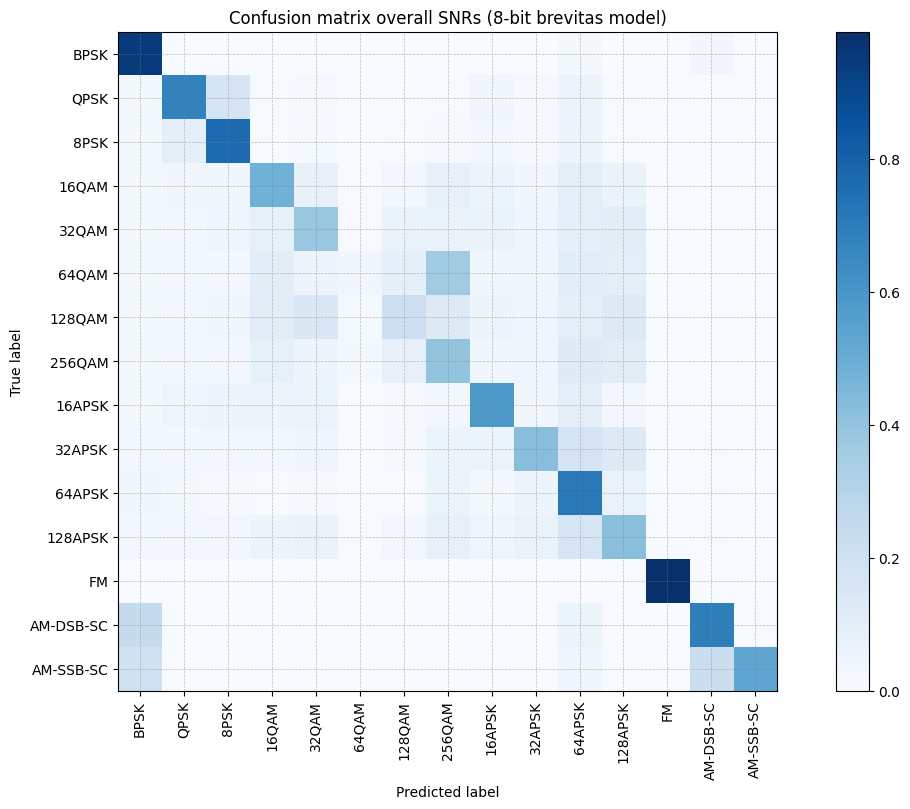

In [20]:
plot_dir=f'{build_dir}/report'
report_dir= Path(plot_dir)
report_dir.mkdir(exist_ok=True)

# Plot overall confusion matrix
def plot_confusion_matrix(cm, title=f'Confusion matrix overall SNRs ({model_input_bit}-bit brevitas model)', cmap=plt.cm.Blues, labels=[]):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=90)
    plt.yticks(tick_marks, labels)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.grid(visible=True, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    # plt.savefig(f'{plot_dir}/{title.lower().replace(" ","_")}.jpeg', bbox_inches='tight',format='jpeg')
    plt.savefig(f'{plot_dir}/{title.lower().replace(" ","_")}', bbox_inches='tight')
   
conf = np.zeros([len(dataset.mod_classes),len(dataset.mod_classes)])
confnorm = np.zeros([len(dataset.mod_classes),len(dataset.mod_classes)])
for i in range(len(y_exp)):
    j = int(y_exp[i])
    k = int(np.argmax(y_pred[i,:]))
    conf[j,k] = conf[j,k] + 1
for i in range(0,len(dataset.mod_classes)):
    confnorm[i,:] = conf[i,:] / np.sum(conf[i,:])

plt.figure(figsize=(12,8))
plot_confusion_matrix(confnorm, labels=dataset.mod_classes)

cor = np.sum(np.diag(conf))
ncor = np.sum(conf) - cor
print("Overall Accuracy across all SNRs: %f"%(cor / (cor+ncor)))

## Confusion Matrix at 4 specific SNRs
Notice how the accuracy is very low at lower SNR and the accuracy is very high at higher SNR

<Figure size 1600x1000 with 0 Axes>

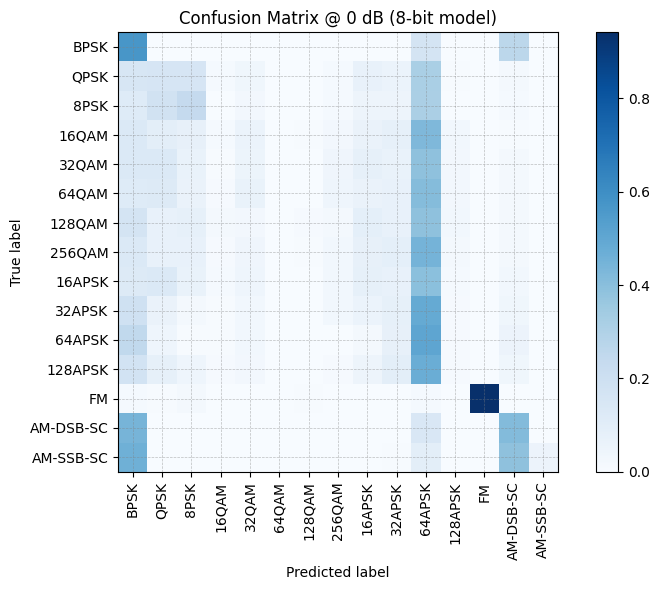

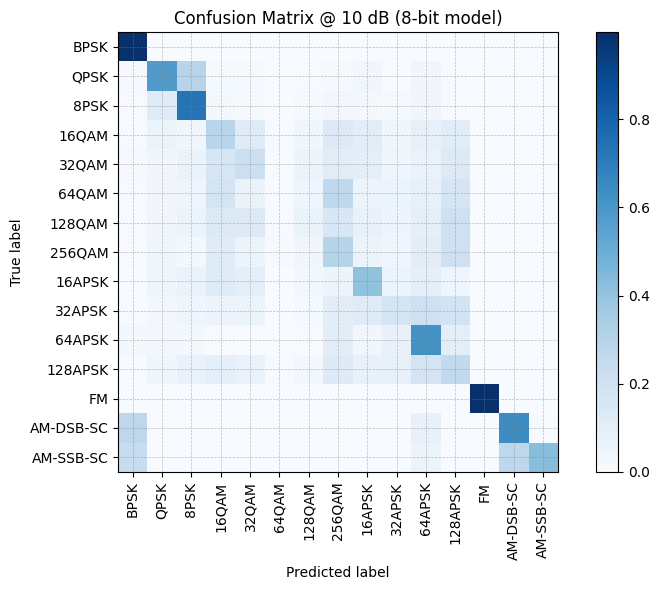

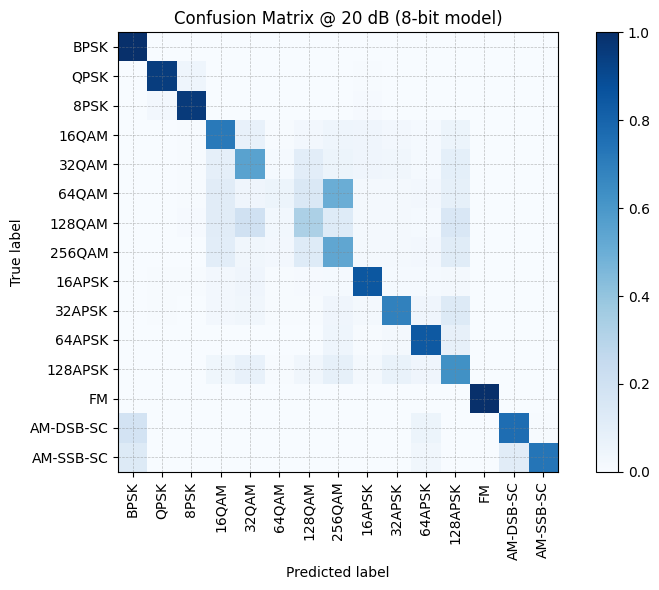

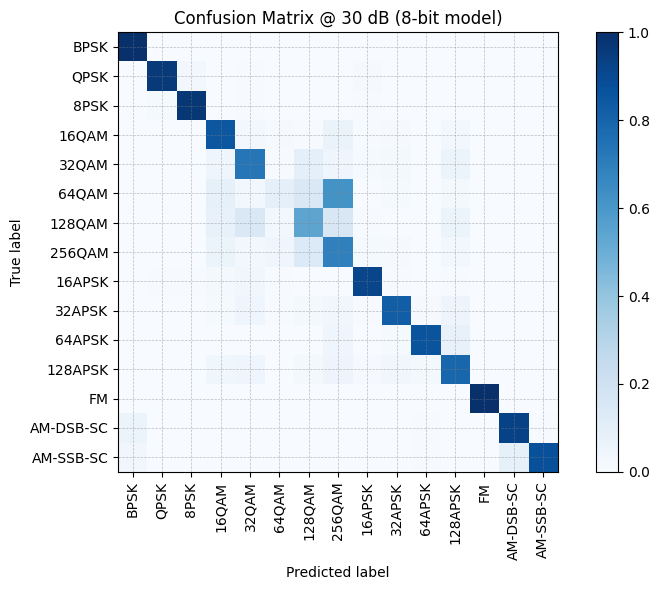

In [21]:
# Plot confusion matrices at 4 different SNRs
snr_to_plot = [0,10,20,30]
plt.figure(figsize=(16,10))
acc = []

# We also want to report accuracy above some SNR
snr_index_lb=3    #13 is the index of +6dB
snr_lb_cor=0
snr_lb_total=0
for snr in dataset.snr_classes:
    # extract classes @ SNR
    indices_snr = (y_snr == snr).nonzero()
    y_exp_i = y_exp[indices_snr]
    y_pred_i = y_pred[indices_snr]
 
    conf = np.zeros([len(dataset.mod_classes),len(dataset.mod_classes)])
    confnorm = np.zeros([len(dataset.mod_classes),len(dataset.mod_classes)])
    for i in range(len(y_exp_i)):
        j = int(y_exp_i[i])
        k = int(np.argmax(y_pred_i[i,:]))
        conf[j,k] = conf[j,k] + 1
    for i in range(0,len(dataset.mod_classes)):
        confnorm[i,:] = conf[i,:] / np.sum(conf[i,:])

    #Plot all matrices in 1 figure
    # if snr in snr_to_plot:
    #     plot, = np.where(snr_to_plot == snr)[0]
    #     plt.subplot(221+plot)
    #     plot_confusion_matrix(confnorm, labels=dataset.mod_classes, title="Confusion Matrix @ %d dB"%(snr))
    
    # Plot each SNR in a separate figure
    if snr in snr_to_plot:
        plt.figure(figsize=(8, 6))
        plot_confusion_matrix(confnorm, labels=dataset.mod_classes, title=f"Confusion Matrix @ {int(snr)} dB ({model_input_bit}-bit model)")
        plt.tight_layout()
        plt.show()
 
    cor = np.sum(np.diag(conf))
    ncor = np.sum(conf) - cor
    acc.append(cor/(cor+ncor))
    
    if (snr>=snr_index_lb):
        snr_lb_cor+= cor
        snr_lb_total+= cor+ncor

## Accuracy over SNRs

Accuracy @ highest SNR (30.0 dB): 0.801793
Accuracy @ >= SNR(6.0 dB): 0.596740
Accuracy overall: 0.550520
SNR [0.0]: 0.20994295028524856
SNR [2.0]: 0.24400977995110024
SNR [4.0]: 0.2859005704971475
SNR [6.0]: 0.3287693561532192
SNR [8.0]: 0.38125509372453137
SNR [10.0]: 0.4469437652811736
SNR [12.0]: 0.5002444987775061
SNR [14.0]: 0.556642216788916
SNR [16.0]: 0.6122249388753056
SNR [18.0]: 0.6674816625916871
SNR [20.0]: 0.7062754686226569
SNR [22.0]: 0.7383863080684596
SNR [24.0]: 0.7607171964140179
SNR [26.0]: 0.7806030969845151
SNR [28.0]: 0.787123064384678
SNR [30.0]: 0.8017929910350449


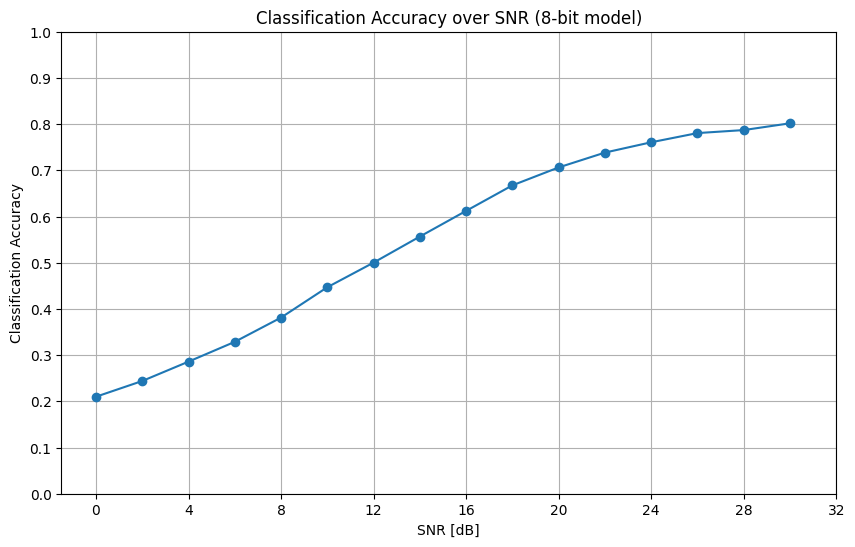

In [22]:
# Plot accuracy over SNR
plt.figure(figsize=(10,6))
plt.plot(dataset.snr_classes, acc, marker='o')
plt.xlabel("SNR [dB]")
plt.xticks(np.arange(snr_lower_bound, snr_upper_bound+2.0*snr_steps, 2.0*snr_steps))
plt.ylabel("Classification Accuracy")
plt.yticks(np.arange(0, 1.1, 0.1))
title=f"Classification Accuracy over SNR ({model_input_bit}-bit model)"
plt.title(title)
plt.grid()
plt.savefig(f'{plot_dir}/{title.lower().replace(" ","_")}.jpeg', bbox_inches='tight',format='jpeg')
# plt.title("Classification Accuracy over SNR");

print(f"Accuracy @ highest SNR ({snr_upper_bound} dB): %f"%(acc[-1]))
print(f"Accuracy @ >= SNR({dataset.snr_classes[snr_index_lb]} dB): {snr_lb_cor/snr_lb_total:.6f}")
print("Accuracy overall: %f"%(np.mean(acc)))
for i, a in enumerate(acc):
    print(f"SNR [{snr_lower_bound + snr_steps*i}]: {a}")

## Breakdown of the accuracy of each modulations over SNRs

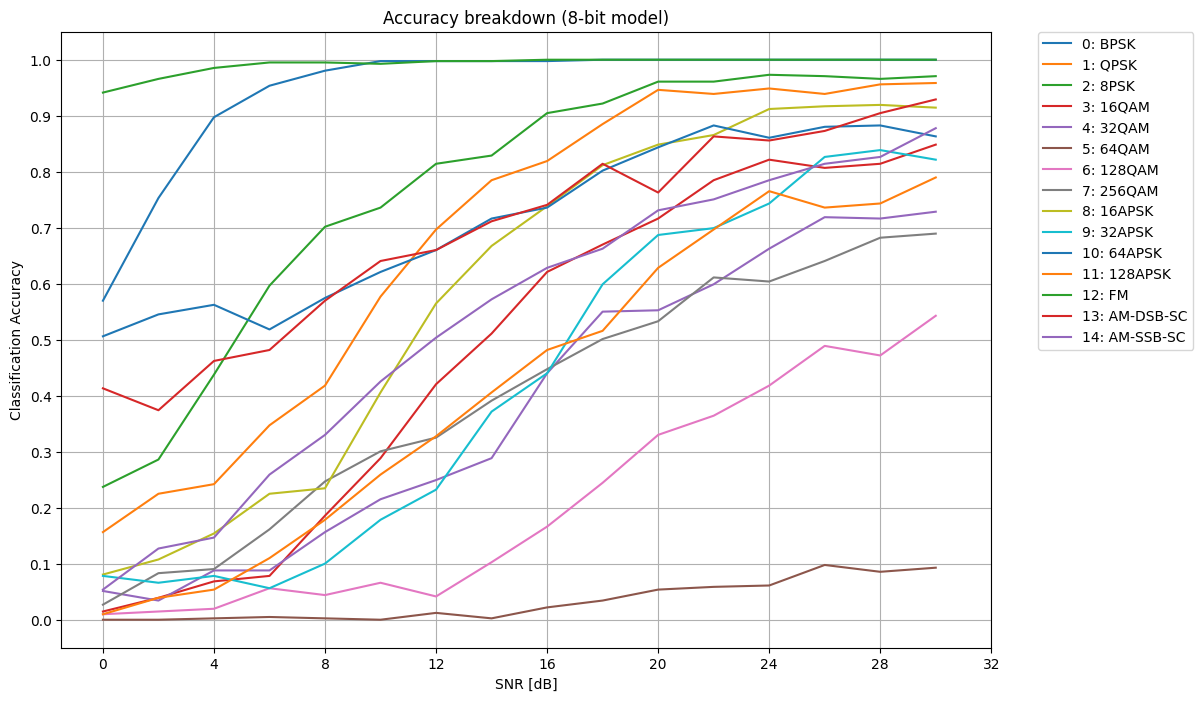

In [23]:
# Plot accuracy per modulation
accs = []
for mod in range(len(dataset.mod_classes)):
    accs.append([])
    for snr in dataset.snr_classes:
        indices = ((y_exp == mod) & (y_snr == snr)).nonzero()
        y_exp_i = y_exp[indices]
        y_pred_i = y_pred[indices]
        cor = np.count_nonzero(y_exp_i == np.argmax(y_pred_i, axis=1))
        accs[mod].append(cor/len(y_exp_i))
        
# Plot accuracy-over-SNR curve
plt.figure(figsize=(12,8))
for mod in range(len(dataset.mod_classes)):
    if accs[mod][-1] < 0.95 or accs[mod][0] > 0.1:
        color = None
    else:
        color = "black"
    plt.plot(dataset.snr_classes, accs[mod], label=str(mod) + ": " + dataset.mod_classes[mod], color=color)
plt.xlabel("SNR [dB]")
plt.xticks(np.arange(snr_lower_bound, snr_upper_bound+2.0*snr_steps, 2.0*snr_steps))
plt.ylabel("Classification Accuracy")
plt.yticks(np.arange(0, 1.1, 0.1))
title=f"Accuracy breakdown ({model_input_bit}-bit model)"
plt.title(title)
plt.grid()
plt.legend(bbox_to_anchor=(1.05, 1),   # position legend outside the right edge
    loc='upper left',           # anchor point of the legend box
    borderaxespad=0.)
plt.savefig(f'{plot_dir}/{title.lower().replace(" ","_")}.jpeg', bbox_inches='tight',format='jpeg')


## Export model as QONNX (Quantized ONNX) file

QONNX is just a extended version of ONNX file. 

QONNX file is still saved under the extension `.onnx`, but their parameters are quantized

To standardize the project, we will call:
- QONNX Model exported from Brevitas: `_brevitas.onnx`
- QONNX Model after network surgery: `_finn.onnx`

Further information about FINN-ONNX and network surgery is explained in the `build_transformed_model.ipynb`

### Clean up the model so that FINN can regconize nodes

Ensure the model is cleaned up before converting to FINN ONNX, so that the nodes in the model are correctly labeled. Otherwise, when we convert to FINN-ONNX, the converter may not be able to regconize the nodes.

Source code for cleanup(): https://github.com/fastmachinelearning/qonnx/blob/main/src/qonnx/util/cleanup.py

In [24]:
from qonnx.util.cleanup import cleanup as qonnx_cleanup
from brevitas.export import export_qonnx
from qonnx.util.cleanup import cleanup as qonnx_cleanup

model.eval()

export_qonnx(model.to('cuda'), torch.randn(1, 2, 1024).to('cuda'), export_path=export_path);

qonnx_cleanup(export_path, out_file=export_path)
print(f'model is saved in {export_path}')

model is saved in rician_matgen_ppm0_2026_jan15_report/mat_gen_4bit/onnx_models/matgen_ppm0_brevitas.onnx
